In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv('almaty_psc_hospital_wrangled.csv')

def classify_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['review_rating'].apply(classify_sentiment)
df['sentiment'].value_counts()


sentiment
positive    11490
negative    11039
neutral       936
Name: count, dtype: int64

In [3]:
X = df['review_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
model_lr = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000))
model_nb = make_pipeline(TfidfVectorizer(), MultinomialNB())


In [5]:
param_grid_lr = {
    'logisticregression__C': [0.1, 1, 10],
    'logisticregression__solver': ['liblinear', 'saga']
}

grid_search_lr = GridSearchCV(model_lr, param_grid_lr, cv=5, n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

print(f"Best Hyperparameters for Logistic Regression: {grid_search_lr.best_params_}")


Best Hyperparameters for Logistic Regression: {'logisticregression__C': 1, 'logisticregression__solver': 'saga'}


In [6]:
# Example of adjusting class weights manually in Logistic Regression:
model_lr_weighted = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000, class_weight={0: 1, 1: 5, 2: 10}))


In [7]:
param_grid_nb = {
    'multinomialnb__alpha': [0.1, 1.0, 10.0]
}

grid_search_nb = GridSearchCV(model_nb, param_grid_nb, cv=5, n_jobs=-1)
grid_search_nb.fit(X_train, y_train)

print(f"Best Hyperparameters for Naive Bayes: {grid_search_nb.best_params_}")


Best Hyperparameters for Naive Bayes: {'multinomialnb__alpha': 0.1}


In [8]:
best_lr = grid_search_lr.best_estimator_
best_nb = grid_search_nb.best_estimator_

best_lr.fit(X_train, y_train)
best_nb.fit(X_train, y_train)


,steps,"[('tfidfvectorizer', ...), ('multinomialnb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [9]:
y_pred_lr = best_lr.predict(X_test)
y_pred_nb = best_nb.predict(X_test)

print("Logistic Regression Evaluation:")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

print("Naive Bayes Evaluation:")
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))


Logistic Regression Evaluation:
              precision    recall  f1-score   support

    negative       0.87      0.94      0.90      2202
     neutral       0.00      0.00      0.00       189
    positive       0.92      0.92      0.92      2302

    accuracy                           0.89      4693
   macro avg       0.59      0.62      0.61      4693
weighted avg       0.86      0.89      0.87      4693

[[2071    1  130]
 [ 128    0   61]
 [ 192    1 2109]]
Naive Bayes Evaluation:
              precision    recall  f1-score   support

    negative       0.82      0.96      0.89      2202
     neutral       0.00      0.00      0.00       189
    positive       0.94      0.87      0.90      2302

    accuracy                           0.88      4693
   macro avg       0.59      0.61      0.60      4693
weighted avg       0.85      0.88      0.86      4693

[[2105    0   97]
 [ 154    0   35]
 [ 296    0 2006]]


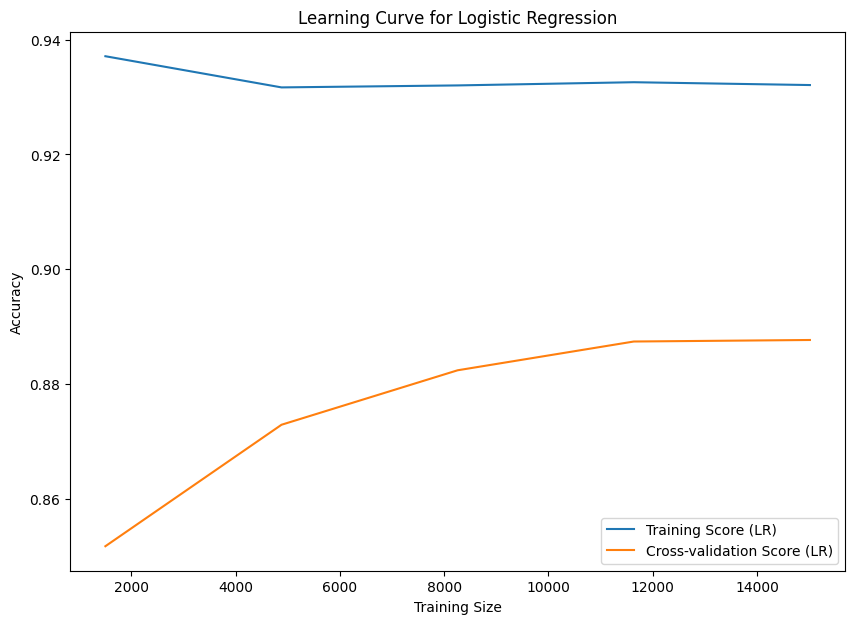

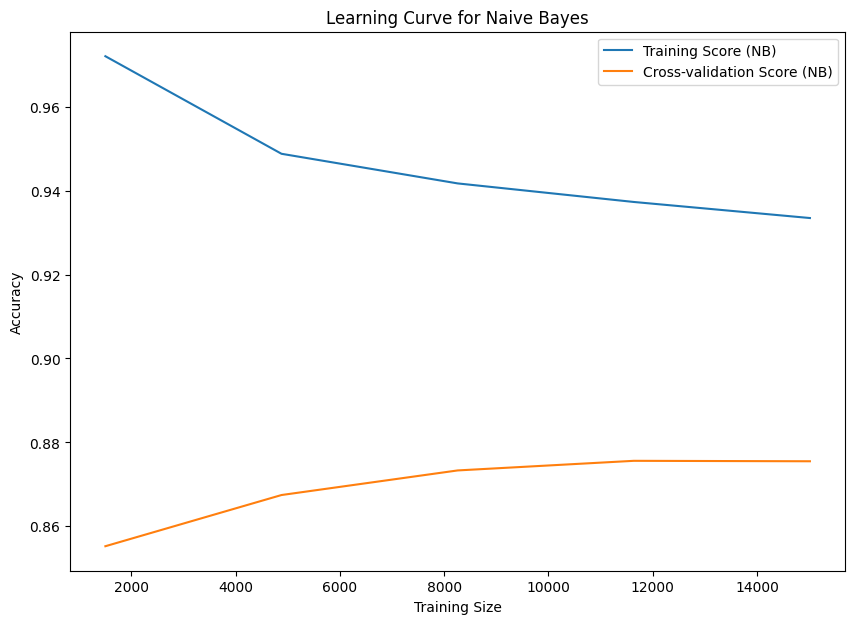

In [10]:
train_sizes_lr, train_scores_lr, test_scores_lr = learning_curve(best_lr, X_train, y_train, cv=5, n_jobs=-1)
train_sizes_nb, train_scores_nb, test_scores_nb = learning_curve(best_nb, X_train, y_train, cv=5, n_jobs=-1)

train_mean_lr = train_scores_lr.mean(axis=1)
test_mean_lr = test_scores_lr.mean(axis=1)

train_mean_nb = train_scores_nb.mean(axis=1)
test_mean_nb = test_scores_nb.mean(axis=1)

plt.figure(figsize=(10, 7))
plt.plot(train_sizes_lr, train_mean_lr, label="Training Score (LR)")
plt.plot(train_sizes_lr, test_mean_lr, label="Cross-validation Score (LR)")
plt.title("Learning Curve for Logistic Regression")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(train_sizes_nb, train_mean_nb, label="Training Score (NB)")
plt.plot(train_sizes_nb, test_mean_nb, label="Cross-validation Score (NB)")
plt.title("Learning Curve for Naive Bayes")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [11]:
from sklearn.preprocessing import LabelEncoder

# Encode the target labels to numeric
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


In [12]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression with class weights
model_lr_weighted = make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=1000, class_weight='balanced'))
model_lr_weighted.fit(X_train, y_train)

# Naive Bayes does not support class_weight, but we'll proceed with regular Naive Bayes for comparison
model_nb = make_pipeline(TfidfVectorizer(), MultinomialNB())
model_nb.fit(X_train, y_train)


,steps,"[('tfidfvectorizer', ...), ('multinomialnb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [13]:
# Logistic Regression Prediction
y_pred_lr = model_lr_weighted.predict(X_test)

# Naive Bayes Prediction
y_pred_nb = model_nb.predict(X_test)


In [14]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Calculate accuracy for Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# Print the accuracies
print(f"Logistic Regression Accuracy: {accuracy_lr}")
print(f"Naive Bayes Accuracy: {accuracy_nb}")


Logistic Regression Accuracy: 0.8548902620924782
Naive Bayes Accuracy: 0.8747070104410825


In [15]:
# Check the class distribution
print(df['sentiment'].value_counts())


sentiment
positive    11490
negative    11039
neutral       936
Name: count, dtype: int64


In [29]:
new_review = ["нормально."]

predicted_sentiment_lr = best_lr.predict(new_review)
predicted_sentiment_nb = best_nb.predict(new_review)

print(f"Logistic Regression Prediction: {predicted_sentiment_lr[0]}")
print(f"Naive Bayes Prediction: {predicted_sentiment_nb[0]}")


Logistic Regression Prediction: positive
Naive Bayes Prediction: negative


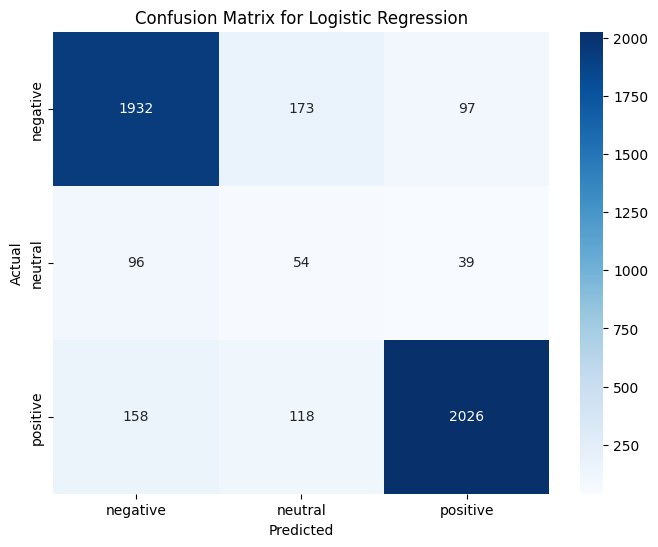

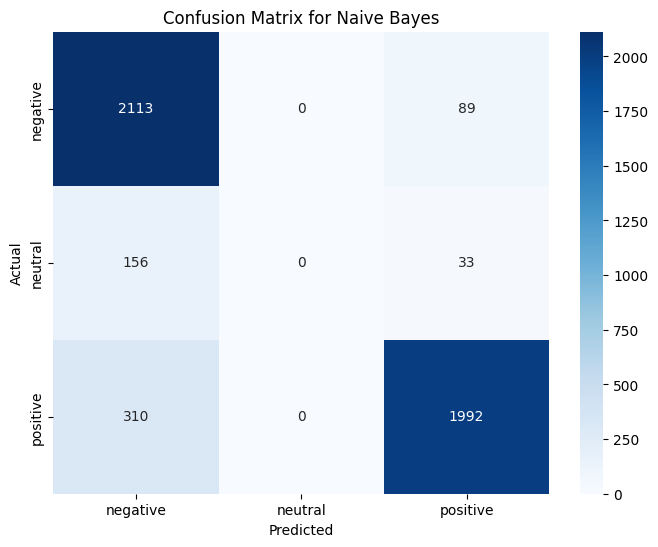

In [17]:
import seaborn as sns
# Confusion Matrix for Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for Naive Bayes
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for Naive Bayes")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [21]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# Ваши данные
df = pd.read_csv('almaty_psc_hospital_wrangled.csv')

# Преобразование рейтинга в классификацию
def classify_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['review_rating'].apply(classify_sentiment)

# Определим X и y
X = df['review_text']
y = df['sentiment']

# Применяем undersampling
# Инициализация RandomUnderSampler
undersample = RandomUnderSampler(sampling_strategy='auto', random_state=42)

# Обучение модели на сбалансированных данных
X_res, y_res = undersample.fit_resample(X.values.reshape(-1, 1), y)

# Печать нового распределения классов
print(pd.Series(y_res).value_counts())


sentiment
negative    936
neutral     936
positive    936
Name: count, dtype: int64


Logistic Regression Evaluation:
Accuracy: 0.6512455516014235
              precision    recall  f1-score   support

    negative       0.64      0.63      0.64       191
     neutral       0.54      0.58      0.56       200
    positive       0.81      0.75      0.78       171

    accuracy                           0.65       562
   macro avg       0.67      0.66      0.66       562
weighted avg       0.66      0.65      0.65       562

[[121  63   7]
 [ 60 117  23]
 [  7  36 128]]

Random Forest Evaluation:
Accuracy: 0.608540925266904
              precision    recall  f1-score   support

    negative       0.59      0.64      0.62       191
     neutral       0.52      0.46      0.49       200
    positive       0.72      0.74      0.73       171

    accuracy                           0.61       562
   macro avg       0.61      0.62      0.61       562
weighted avg       0.60      0.61      0.61       562

[[123  54  14]
 [ 72  92  36]
 [ 12  32 127]]


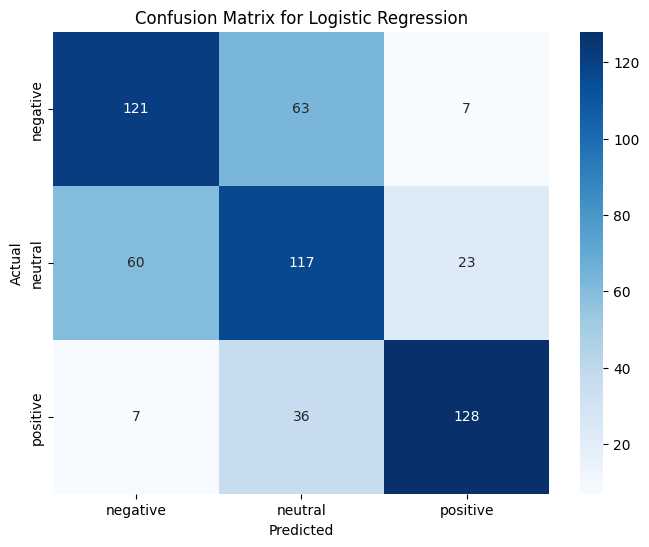

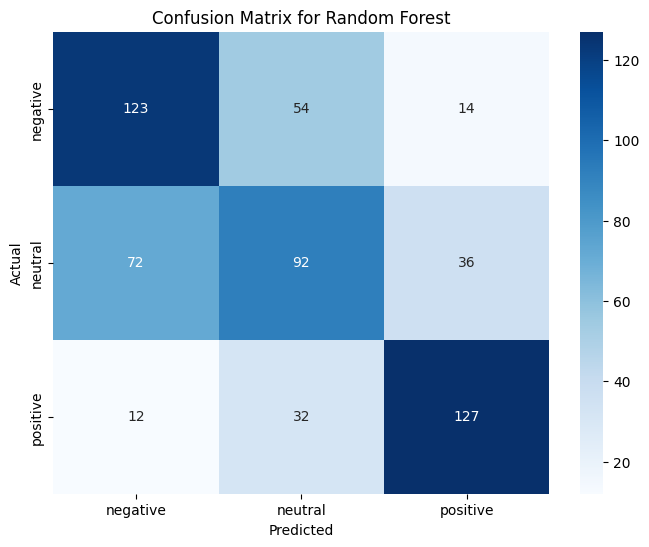

In [ ]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# Разделяем данные на обучающие и тестовые
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Преобразуем текстовые данные в числовые с помощью TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train.ravel())
X_test_tfidf = tfidf.transform(X_test.ravel())

# Модели: Logistic Regression и Random Forest

# Logistic Regression
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
model_lr.fit(X_train_tfidf, y_train)
y_pred_lr = model_lr.predict(X_test_tfidf)

# Random Forest
model_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
model_rf.fit(X_train_tfidf, y_train)
y_pred_rf = model_rf.predict(X_test_tfidf)

# Оценка модели Logistic Regression
print("Logistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)}")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

# Оценка модели Random Forest
print("\nRandom Forest Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

# Визуализация Confusion Matrix для Logistic Regression
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues", xticklabels=model_lr.classes_, yticklabels=model_lr.classes_)
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Визуализация Confusion Matrix для Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues", xticklabels=model_rf.classes_, yticklabels=model_rf.classes_)
plt.title("Confusion Matrix for Random Forest")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [30]:
new_review = ["нормально"]  
predicted_sentiment_lr = model_lr.predict(tfidf.transform(new_review))
predicted_sentiment_rf = model_rf.predict(tfidf.transform(new_review))

print(f"Logistic Regression Prediction: {predicted_sentiment_lr[0]}")
print(f"Random Forest Prediction: {predicted_sentiment_rf[0]}")

Logistic Regression Prediction: neutral
Random Forest Prediction: neutral
